<a href="https://colab.research.google.com/github/KingKouame/KingKouame/blob/main/decision_tree_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# You can also drop whichever other columns you'd like here

df.drop("Cabin", axis=1, inplace=True)

### One-Hot Encoding
One-hot encoding is a technique used to ensure that categorical variables are better represented in the machine. Let's take a look at the "Sex" column

In [9]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

Machine Learning classifiers don't know how to handle strings. As a result, you need to convert it into a categorical representation. There are two main ways to go about this:

Label Encoding: Assigning, for example, 0 for "male" and 1 for "female". The problem here is it intrinsically makes one category "larger than" the other category.

One-hot encoding: Assigning, for example, [1, 0] for "male" and [0, 1] for female. In this case, you have an array of size (n_categories,) and you represent a 1 in the correct index, and 0 elsewhere. In Pandas, this would show as extra columns. For example, rather than having a "Sex" column, it would be a "Sex_male" and "Sex_female" column. Then, if the person is male, it would simply show as a 1 in the "Sex_male" column and a 0 in the "Sex_female" column.

There is a nice and easy method that does this in pandas: get_dummies()

In [7]:
titanic_df = pd.get_dummies(df, prefix="Sex", columns=["Sex"])
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Embarked,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,S,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,S,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,S,True,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,S,False,True


Now, we do the same to the "Embarked" column.

In [8]:
titanic_df = pd.get_dummies(titanic_df, prefix="Embarked", columns=["Embarked"])
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,False,True,False,False,True


In [9]:
# Using relevant variables from the data, we will  split the data into a training, development and test set.

# First we import we numpy library,

import numpy as np

# Then we select relevant variables

relevant_variables = ['Survived', 'Pclass', 'Sex_female', 'Sex_male', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

# And split the data into training, development and test sets

train_data, dev_data, test_data = np.split(titanic_df.loc[:, relevant_variables], [int(0.7 * len(titanic_df)), int(0.85 * len(titanic_df))], axis=0)

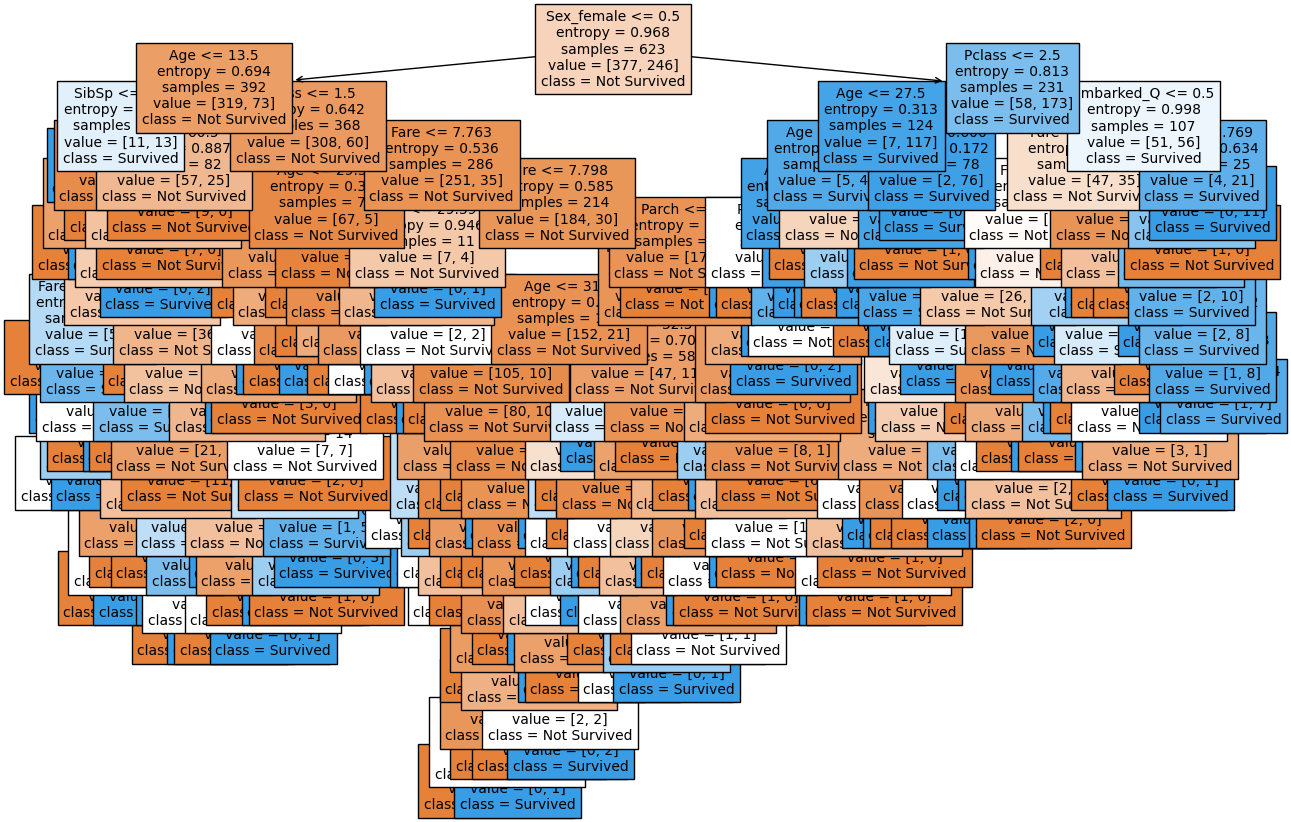

In [10]:
# In order to train a decision tree and make a plot, we need the following libraries,

from sklearn import tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# We first split the data into X and Y,

X_train = train_data.loc[:, train_data.columns != 'Survived']
Y_train = train_data.loc[:, train_data.columns == 'Survived']

# Fill missing values (NaN) in X_train with the mean of each column,

X_train = X_train.fillna(X_train.mean())

# Then we train the decision tree,

decision_tree = tree.DecisionTreeClassifier(criterion='entropy')
decision_tree.fit(X_train, Y_train)

# And finally we plot the tree.

plt.figure(figsize=(15, 10))
plot_tree(decision_tree, feature_names=X_train.columns, class_names=['Not Survived', 'Survived'], fontsize=10, filled=True)
plt.show()

In [11]:
# Computing the model’s accuracy on the development set.

# First we split the data into X and Y,

X_dev = dev_data.loc[:, dev_data.columns != 'Survived']
Y_dev = dev_data.loc[:, dev_data.columns == 'Survived']

# Then we fill missing values (NaN) in X_dev with the mean of each column,

X_dev = X_dev.fillna(X_dev.mean())

# Predict the outcome on the development set,

Y_dev_pred = decision_tree.predict(X_dev)

# Extract the values from the 'Survived' column as a NumPy array

Y_dev_values = Y_dev['Survived'].values

# Finally, we calculate the model's accuracy on the development set,

accuracy = np.sum(Y_dev_pred == Y_dev_values) / len(Y_dev_values)

# Before printing the accuracy.

print("Model's accuracy on the development set:", accuracy)

Model's accuracy on the development set: 0.746268656716418


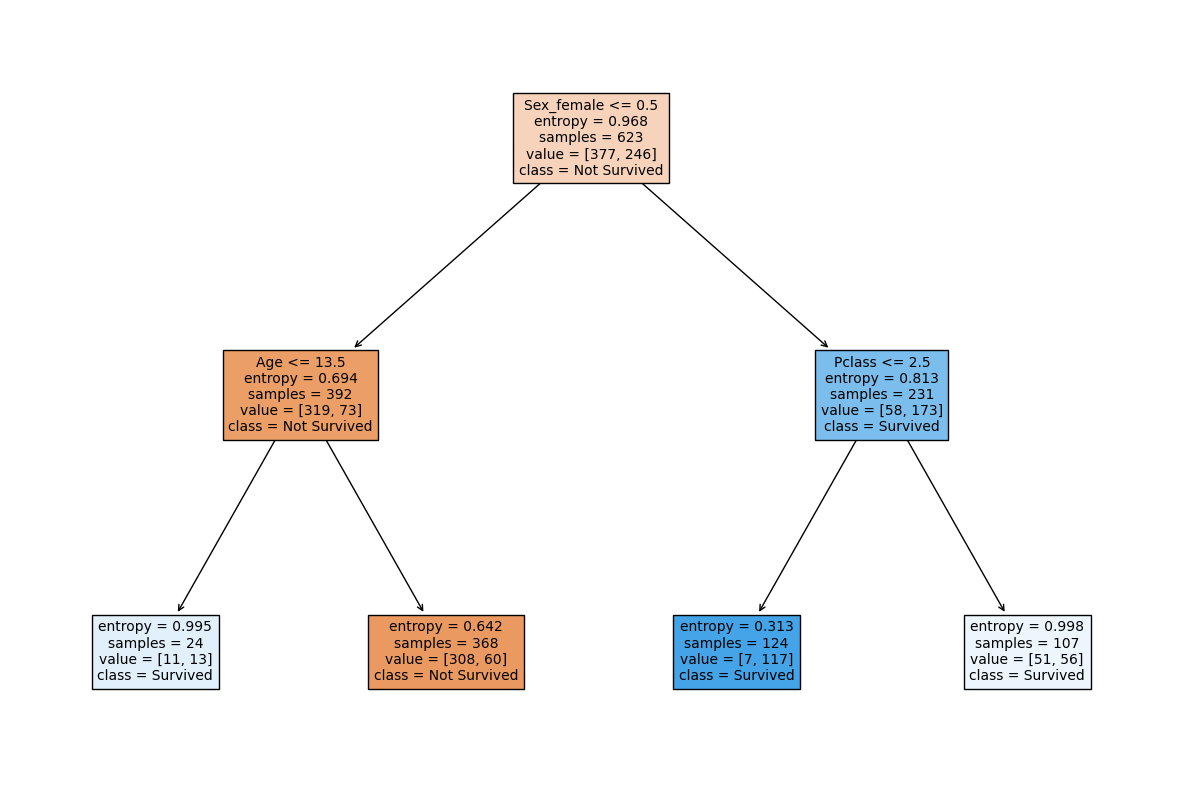

Model's accuracy on the training set with max_depth = 2 : 0.7929373996789727
Model's accuracy on the development set with max_depth = 2 : 0.7686567164179104


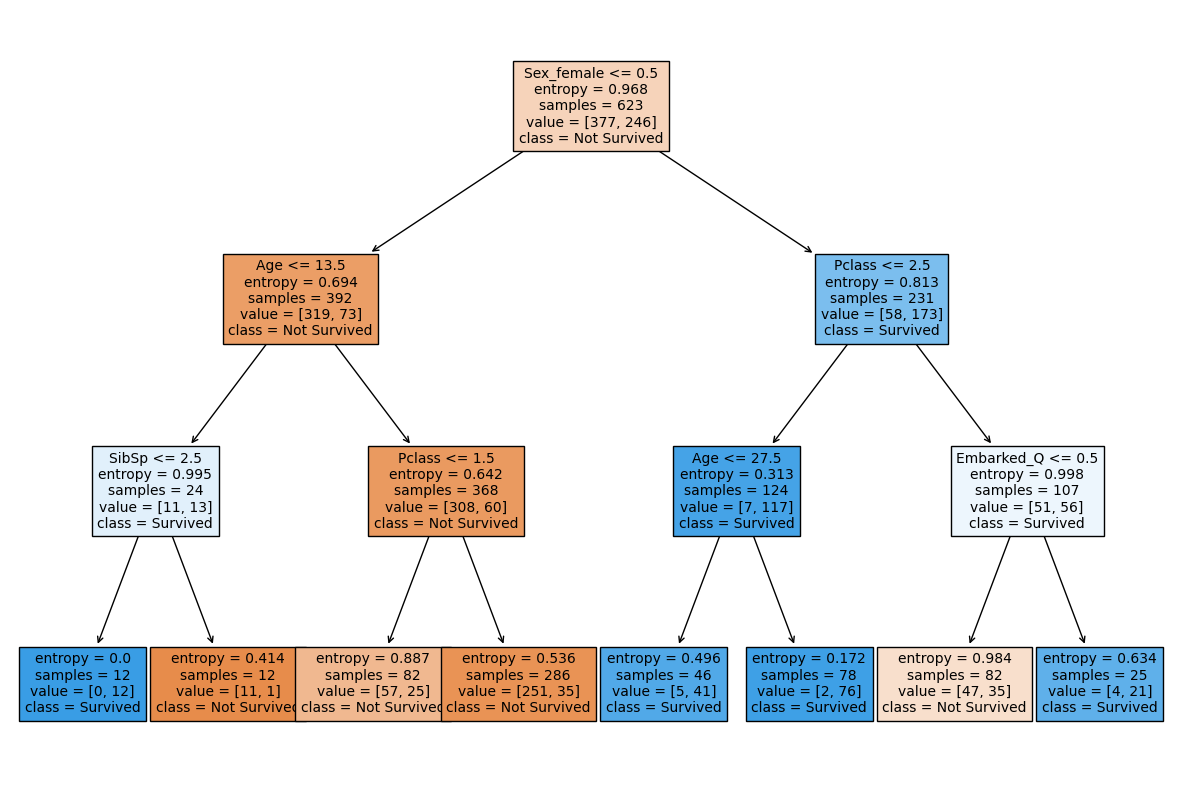

Model's accuracy on the training set with max_depth = 3 : 0.8282504012841091
Model's accuracy on the development set with max_depth = 3 : 0.7910447761194029


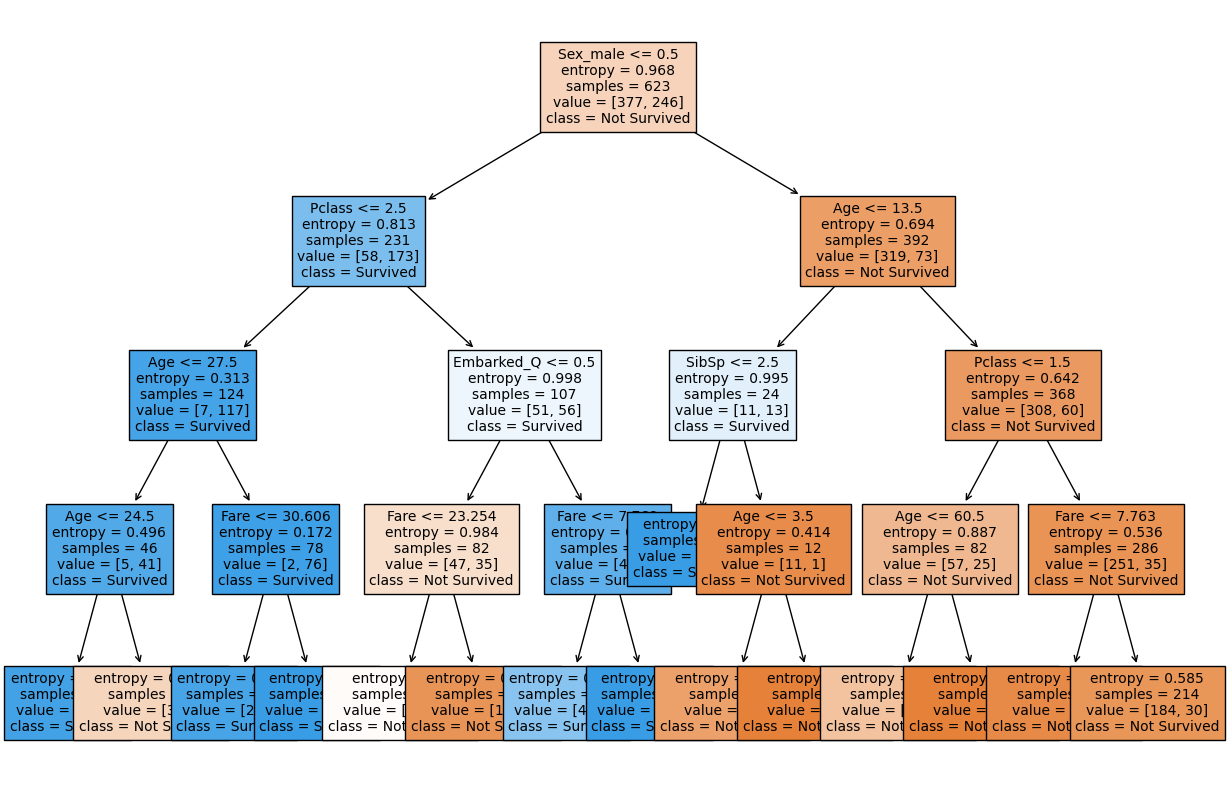

Model's accuracy on the training set with max_depth = 4 : 0.8298555377207063
Model's accuracy on the development set with max_depth = 4 : 0.7835820895522388


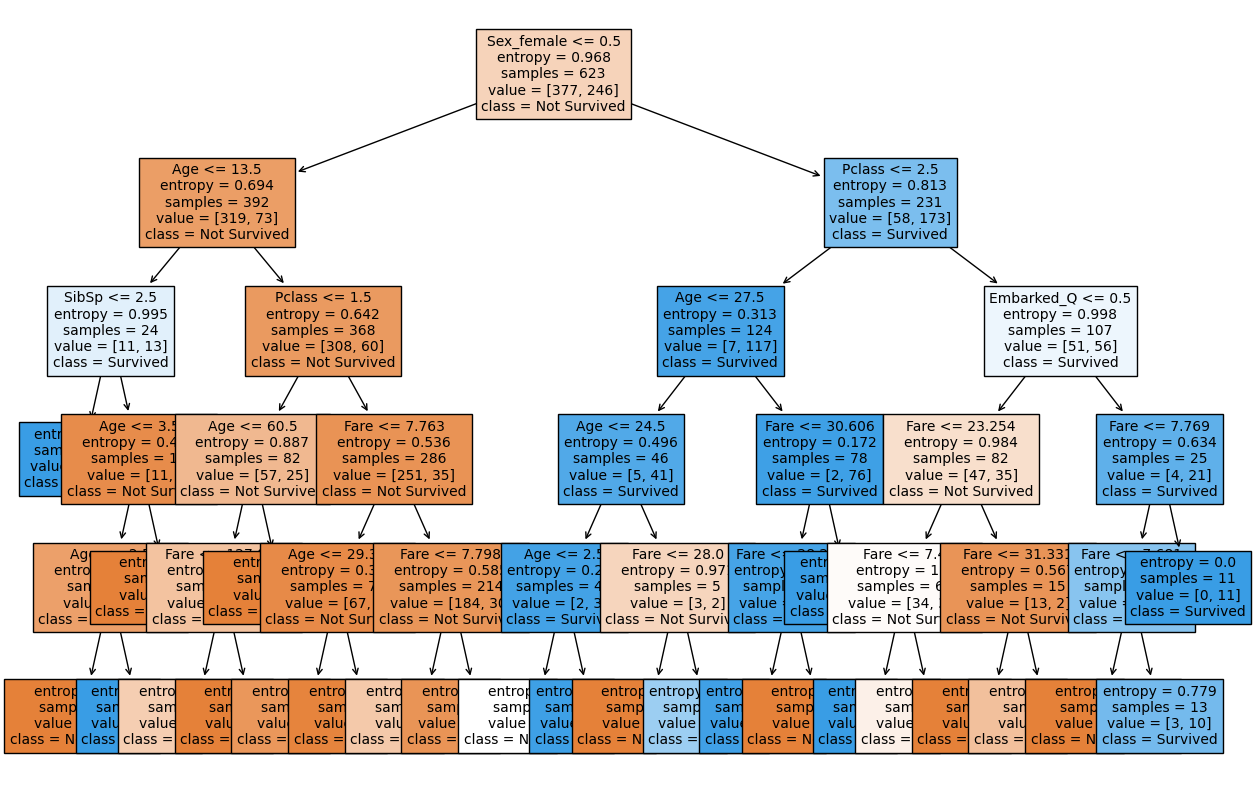

Model's accuracy on the training set with max_depth = 5 : 0.841091492776886
Model's accuracy on the development set with max_depth = 5 : 0.7910447761194029


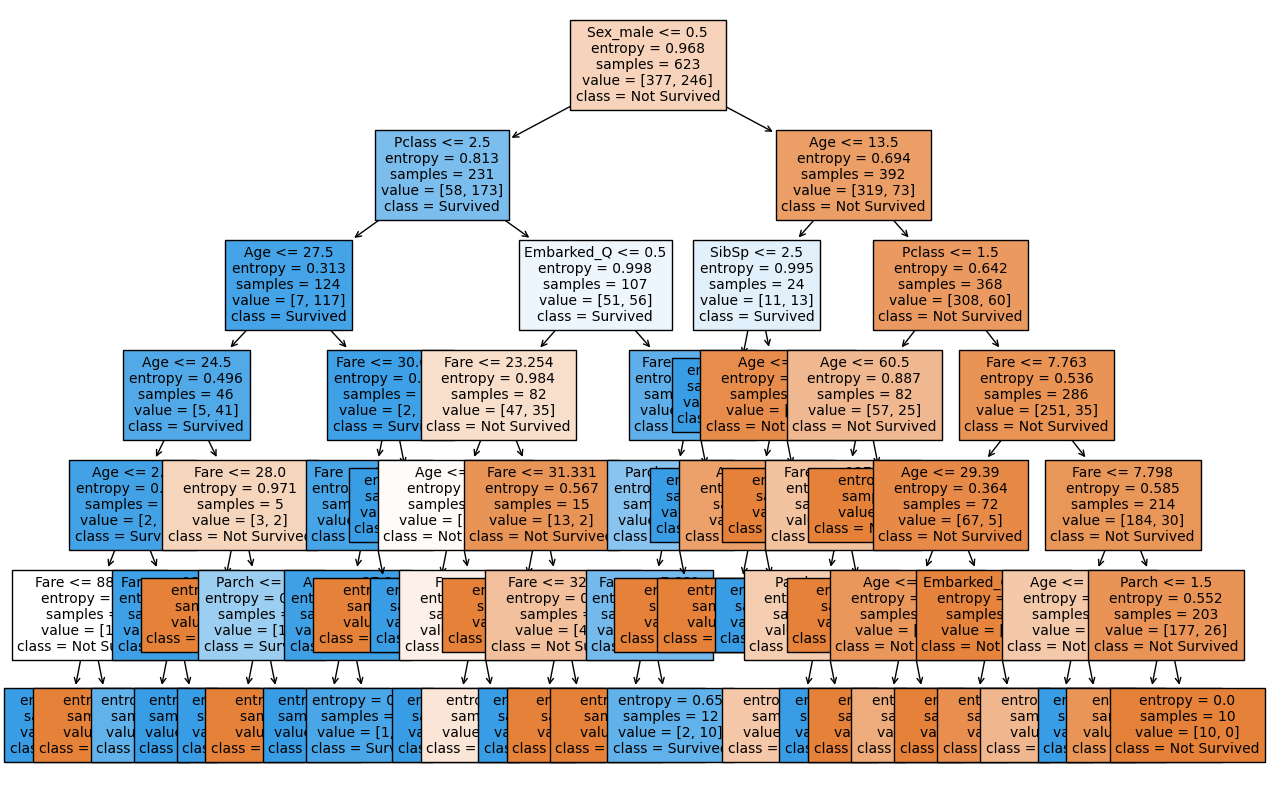

Model's accuracy on the training set with max_depth = 6 : 0.8587479935794543
Model's accuracy on the development set with max_depth = 6 : 0.7761194029850746


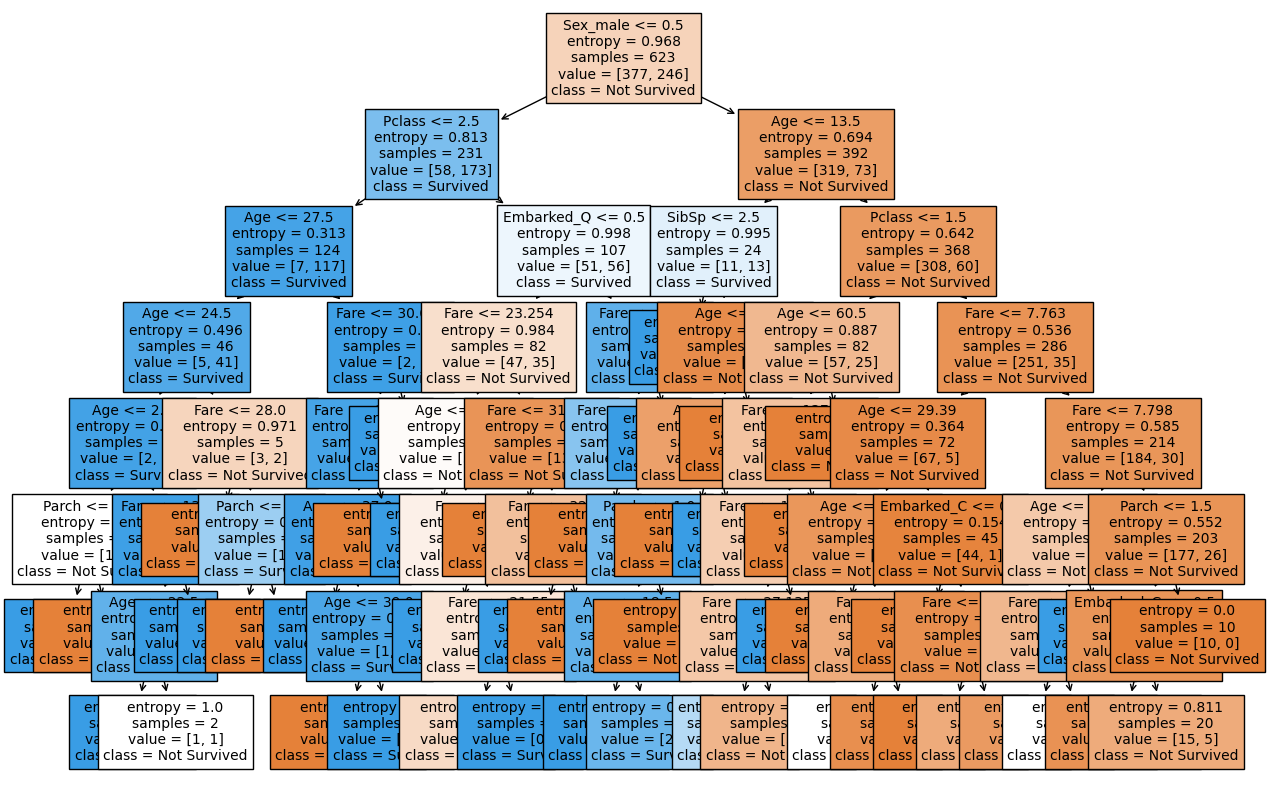

Model's accuracy on the training set with max_depth = 7 : 0.869983948635634
Model's accuracy on the development set with max_depth = 7 : 0.753731343283582


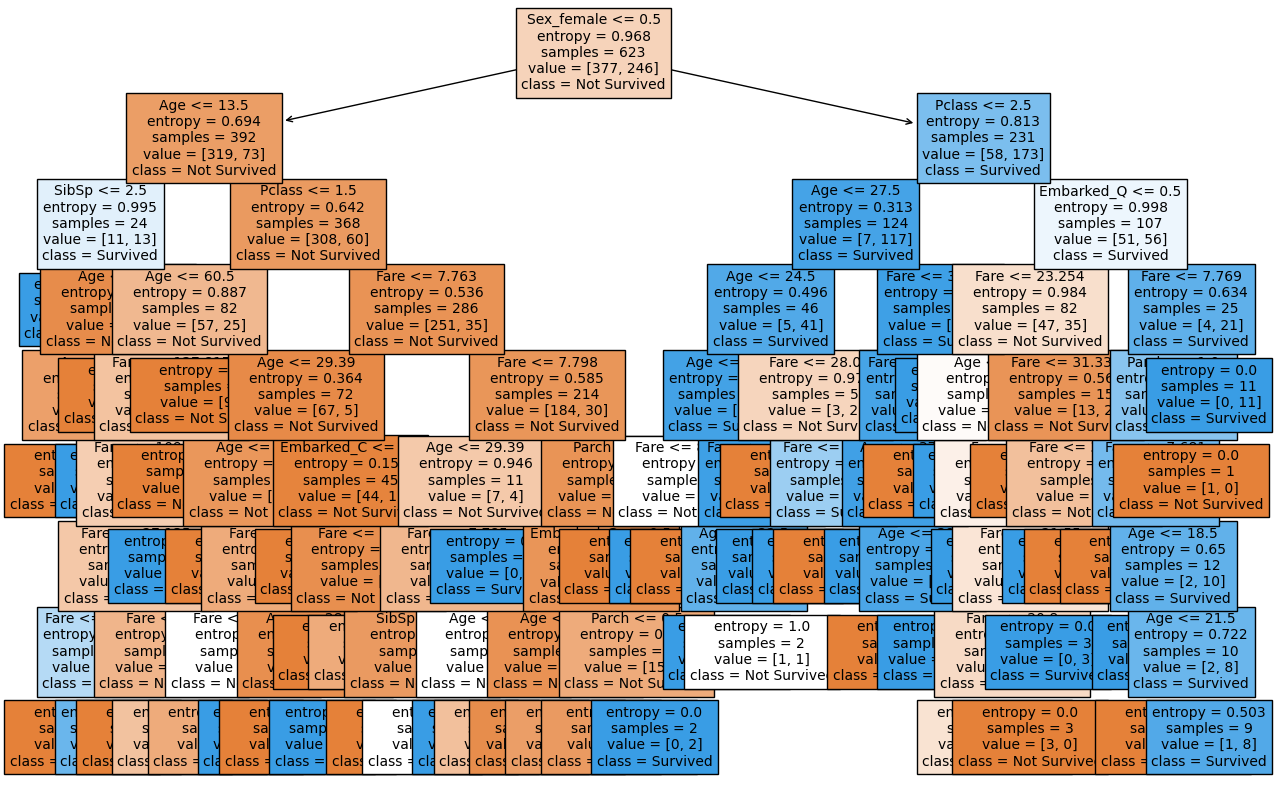

Model's accuracy on the training set with max_depth = 8 : 0.8860353130016051
Model's accuracy on the development set with max_depth = 8 : 0.7611940298507462


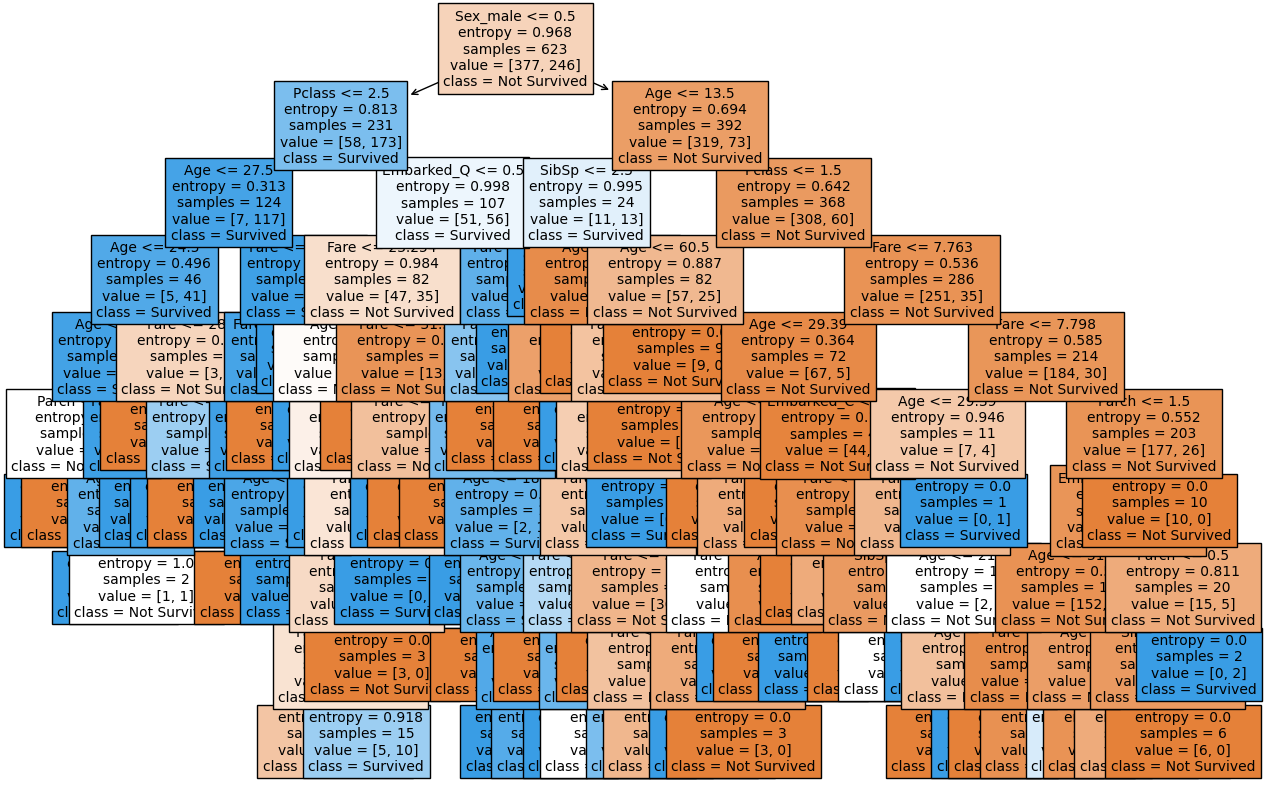

Model's accuracy on the training set with max_depth = 9 : 0.9020866773675762
Model's accuracy on the development set with max_depth = 9 : 0.753731343283582


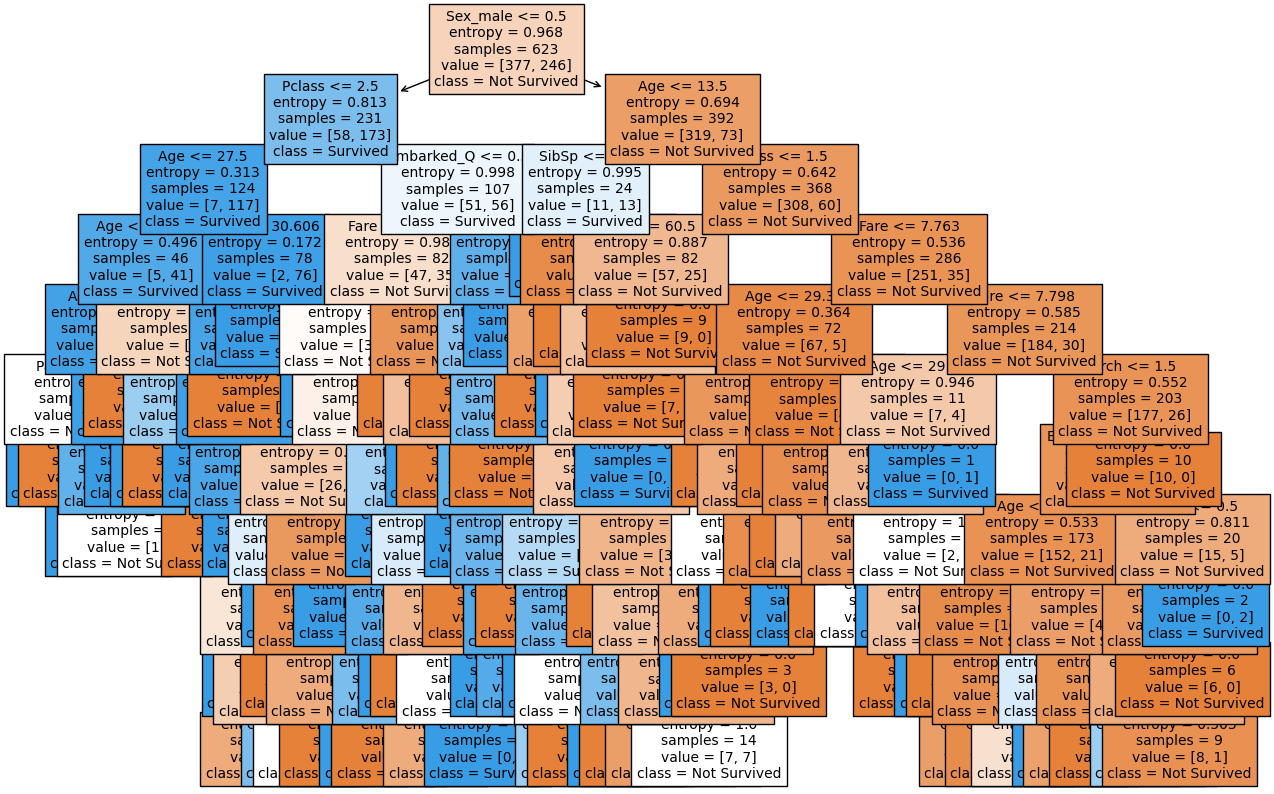

Model's accuracy on the training set with max_depth = 10 : 0.92776886035313
Model's accuracy on the development set with max_depth = 10 : 0.7686567164179104


In [12]:
# Building the model with different values of max_depth (2–10).

accuracies_train = []
accuracies_dev = []

for max_depth in range(2, 11):

  # First we train the decision tree

  decision_tree = tree.DecisionTreeClassifier(criterion='entropy', max_depth=max_depth)
  decision_tree.fit(X_train, Y_train)

  # Calculate the accuracy on the training data

  Y_train_pred = decision_tree.predict(X_train)
  accuracy_train = np.sum(Y_train_pred == Y_train['Survived']) / len(Y_train)
  accuracies_train.append(accuracy_train)

  # Calculate the accuracy on the development data

  Y_dev_pred = decision_tree.predict(X_dev)
  accuracy_dev = np.sum(Y_dev_pred == Y_dev['Survived']) / len(Y_dev)
  accuracies_dev.append(accuracy_dev)

  # Plot the tree

  plt.figure(figsize=(15, 10))
  plot_tree(decision_tree, feature_names=X_train.columns, class_names=['Not Survived', 'Survived'], fontsize=10, filled=True)
  plt.show()

  # Print the accuracy

  print("Model's accuracy on the training set with max_depth =", max_depth, ":", accuracy_train)
  print("Model's accuracy on the development set with max_depth =", max_depth, ":", accuracy_dev)

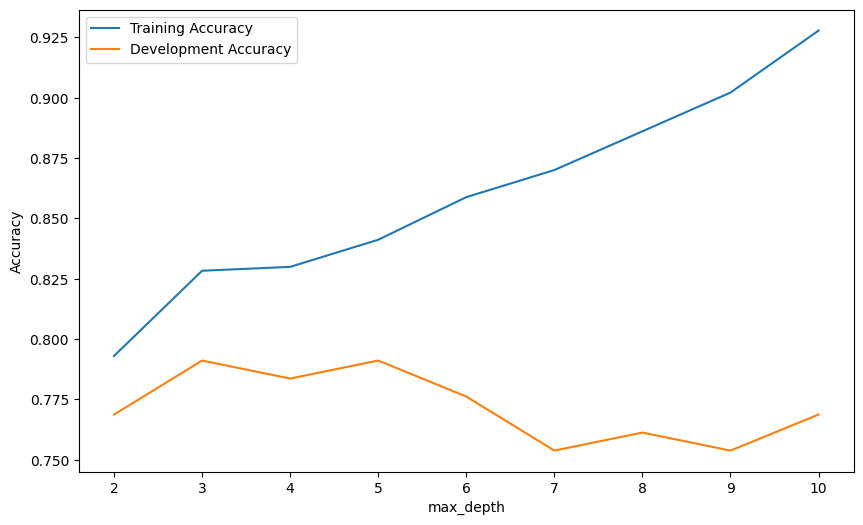

The training accuracy line increases rapidly at first, then levels off.
The development accuracy line increases more slowly, and then decreases slightly.
This shape suggests that the model is overfitting the training data.
This means that the model is learning the specific details of the training data too well, and is not generalizing well to new data.


In [13]:
# Plotting a line of the training accuracies and another of the development accuracies in the same graph.

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), accuracies_train, label="Training Accuracy")
plt.plot(range(2, 11), accuracies_dev, label="Development Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Here is a description of the shape of the lines

print("The training accuracy line increases rapidly at first, then levels off.")
print("The development accuracy line increases more slowly, and then decreases slightly.")

# And the interpretation of the shape of the lines

print("This shape suggests that the model is overfitting the training data.")
print("This means that the model is learning the specific details of the training data too well, and is not generalizing well to new data.")

In [14]:
# Reporting the accuracy of the final model on the test data.

# First we split the data into X and Y,

X_test = test_data.loc[:, test_data.columns != 'Survived']
Y_test = test_data.loc[:, test_data.columns == 'Survived']

# Then we fill missing values (NaN) in X_test with the mean of each column,

X_test = X_test.fillna(X_test.mean())

# We look at predicting the outcome on the test set,

Y_test_pred = decision_tree.predict(X_test)

# Then, extract the values from the 'Survived' column as a NumPy array,

Y_test_values = Y_test['Survived'].values

# Finally, we calculate the model's accuracy on the test set,

accuracy = np.sum(Y_test_pred == Y_test_values) / len(Y_test_values)

# Before printing the accuracy.

print("Model's accuracy on the test set:", accuracy)

Model's accuracy on the test set: 0.8507462686567164
